#  **Step 1: Data Scraping**

Installing & Importing Libraries

In [12]:
import requests

r = requests.get(
    "https://api.jolpi.ca/ergast/f1/2015/driverStandings.json",
    params={"limit": 1, "offset": 0},
    timeout=15
)
data = r.json()["MRData"]

# Walk down layer by layer and print keys at each level
table_key = next(k for k in data if k not in ("xmlns","series","url","limit","offset","total"))
print("Table key:", table_key)

table = data[table_key]
inner_key = next(k for k, v in table.items() if isinstance(v, list))
print("Inner key:", inner_key)

standings_list = table[inner_key][0]
print("\nstandings_list keys:", list(standings_list.keys()))
print("standings_list sample:", standings_list)

Table key: StandingsTable
Inner key: StandingsLists

standings_list keys: ['season', 'round', 'DriverStandings']
standings_list sample: {'season': '2015', 'round': '19', 'DriverStandings': [{'position': '1', 'positionText': '1', 'points': '381', 'wins': '10', 'Driver': {'driverId': 'hamilton', 'permanentNumber': '44', 'code': 'HAM', 'url': 'http://en.wikipedia.org/wiki/Lewis_Hamilton', 'givenName': 'Lewis', 'familyName': 'Hamilton', 'dateOfBirth': '1985-01-07', 'nationality': 'British'}, 'Constructors': [{'constructorId': 'mercedes', 'url': 'https://en.wikipedia.org/wiki/Mercedes-Benz_in_Formula_One', 'name': 'Mercedes', 'nationality': 'German'}]}]}


API helper with pagination

In [13]:
BASE_URL = "https://api.jolpi.ca/ergast/f1"
SEASONS  = list(range(2015, 2025))

def fetch_all(endpoint):
    """Fetch every page from a Jolpica endpoint, return the inner list."""
    results, offset, limit = [], 0, 100
    while True:
        r = requests.get(
            f"{BASE_URL}/{endpoint}.json",
            params={"limit": limit, "offset": offset},
            timeout=15
        )
        r.raise_for_status()
        mrd = r.json()["MRData"]
        total = int(mrd["total"])

        # Find the table key (e.g. "StandingsTable", "RaceTable")
        table_key = next(k for k in mrd if k not in
                         ("xmlns","series","url","limit","offset","total"))
        table = mrd[table_key]

        # Find the inner list (e.g. "StandingsLists", "Races")
        inner_key = next(k for k, v in table.items() if isinstance(v, list))
        results.extend(table[inner_key])

        offset += limit
        if offset >= total:
            break
        time.sleep(0.3)
    return results

print("Helper ready")

Helper ready


Driver standings per season

In [15]:
rows = []

for season in SEASONS:
    print(f"  {season}...", end=" ")
    for standings_list in fetch_all(f"{season}/driverStandings"):
        # Each standings_list is one round's snapshot
        # The actual entries live inside "DriverStandings"
        for entry in standings_list["DriverStandings"]:
            driver = entry["Driver"]
            rows.append({
                "season":      season,
                "round":       standings_list.get("round", ""),
                "position":    int(entry.get("position", 0)), # Use .get() to handle missing 'position' key
                "points":      float(entry["points"]),
                "wins":        int(entry["wins"]),
                "driver_id":   driver["driverId"],
                "driver_name": driver["givenName"] + " " + driver["familyName"],
                "nationality": driver["nationality"],
                "constructor": entry["Constructors"][0]["name"] if entry["Constructors"] else None,
            })
    print("done")
    time.sleep(0.4)

df_drivers = pd.DataFrame(rows)
print(f"\nShape: {df_drivers.shape}")
df_drivers.head()

  2015... done
  2016... done
  2017... done
  2018... done
  2019... done
  2020... done
  2021... done
  2022... done
  2023... done
  2024... done

Shape: (223, 9)


,season,round,position,points,wins,driver_id,driver_name,nationality,constructor
0,2015,19,1,381.0,10,hamilton,Lewis Hamilton,British,Mercedes
1,2015,19,2,322.0,6,rosberg,Nico Rosberg,German,Mercedes
2,2015,19,3,278.0,3,vettel,Sebastian Vettel,German,Ferrari
3,2015,19,4,150.0,0,raikkonen,Kimi Räikkönen,Finnish,Ferrari
4,2015,19,5,136.0,0,bottas,Valtteri Bottas,Finnish,Williams


Constructor standings per season

In [16]:
constructor_rows = []

for season in SEASONS:
    print(f"  Fetching constructor standings: {season}...", end=" ")
    results = fetch_ergast(f"{season}/constructorStandings")

    for standing_list in results:
        round_num = standing_list.get("round", "final")
        for entry in standing_list["ConstructorStandings"]:
            constructor = entry["Constructor"]
            constructor_rows.append({
                "season":           season,
                "round":            round_num,
                "position":         int(entry["position"]),
                "points":           float(entry["points"]),
                "wins":             int(entry["wins"]),
                "constructor_id":   constructor["constructorId"],
                "constructor_name": constructor["name"],
                "nationality":      constructor["nationality"],
            })
    print("✅")
    time.sleep(0.5)

df_constructor_standings = pd.DataFrame(constructor_rows)
print(f"\n📊 Constructor standings shape: {df_constructor_standings.shape}")
display(df_constructor_standings.head())

  Fetching constructor standings: 2015... ✅
  Fetching constructor standings: 2016... ✅
  Fetching constructor standings: 2017... ✅
  Fetching constructor standings: 2018... ✅
  Fetching constructor standings: 2019... ✅
  Fetching constructor standings: 2020... ✅
  Fetching constructor standings: 2021... ✅
  Fetching constructor standings: 2022... ✅
  Fetching constructor standings: 2023... ✅
  Fetching constructor standings: 2024... ✅

📊 Constructor standings shape: (101, 8)


,season,round,position,points,wins,constructor_id,constructor_name,nationality
0,2015,19,1,703.0,16,mercedes,Mercedes,German
1,2015,19,2,428.0,3,ferrari,Ferrari,Italian
2,2015,19,3,257.0,0,williams,Williams,British
3,2015,19,4,187.0,0,red_bull,Red Bull,Austrian
4,2015,19,5,136.0,0,force_india,Force India,Indian


Race results per season (takes ~2–3 mins)

In [17]:
race_result_rows = []

for season in SEASONS:
    print(f"  Fetching race results: {season}...", end=" ")
    results = fetch_ergast(f"{season}/results")

    for race in results:
        race_meta = {
            "season":        season,
            "round":         int(race["round"]),
            "race_name":     race["raceName"],
            "circuit":       race["Circuit"]["circuitName"],
            "country":       race["Circuit"]["Location"]["country"],
            "date":          race["date"],
        }
        for result in race["Results"]:
            driver = result["Driver"]
            constructor = result["Constructor"]
            fastest_lap = result.get("FastestLap", {})
            race_result_rows.append({
                **race_meta,
                "grid_position":    int(result.get("grid", 0)),
                "finish_position":  result.get("position", None),
                "finish_position_order": int(result.get("positionOrder", 0)),
                "points":           float(result.get("points", 0)),
                "laps":             int(result.get("laps", 0)),
                "status":           result.get("status", ""),
                "driver_id":        driver["driverId"],
                "driver_name":      f"{driver['givenName']} {driver['familyName']}",
                "constructor_id":   constructor["constructorId"],
                "constructor_name": constructor["name"],
                "fastest_lap_rank": fastest_lap.get("rank", None),
                "fastest_lap_time": fastest_lap.get("Time", {}).get("time", None),
            })
    print("✅")
    time.sleep(0.5)

df_race_results = pd.DataFrame(race_result_rows)
print(f"\n📊 Race results shape: {df_race_results.shape}")
display(df_race_results.head())

  Fetching race results: 2015... ✅
  Fetching race results: 2016... ✅
  Fetching race results: 2017... ✅
  Fetching race results: 2018... ✅
  Fetching race results: 2019... ✅
  Fetching race results: 2020... ✅
  Fetching race results: 2021... ✅
  Fetching race results: 2022... ✅
  Fetching race results: 2023... ✅
  Fetching race results: 2024... ✅

📊 Race results shape: (4219, 18)


,season,round,race_name,circuit,country,date,grid_position,finish_position,finish_position_order,points,laps,status,driver_id,driver_name,constructor_id,constructor_name,fastest_lap_rank,fastest_lap_time
0,2015,1,Australian Grand Prix,Albert Park Grand Prix Circuit,Australia,2015-03-15,1,1,0,25.0,58,Finished,hamilton,Lewis Hamilton,mercedes,Mercedes,1,1:30.945
1,2015,1,Australian Grand Prix,Albert Park Grand Prix Circuit,Australia,2015-03-15,2,2,0,18.0,58,Finished,rosberg,Nico Rosberg,mercedes,Mercedes,2,1:31.092
2,2015,1,Australian Grand Prix,Albert Park Grand Prix Circuit,Australia,2015-03-15,4,3,0,15.0,58,Finished,vettel,Sebastian Vettel,ferrari,Ferrari,4,1:31.457
3,2015,1,Australian Grand Prix,Albert Park Grand Prix Circuit,Australia,2015-03-15,3,4,0,12.0,58,Finished,massa,Felipe Massa,williams,Williams,6,1:31.719
4,2015,1,Australian Grand Prix,Albert Park Grand Prix Circuit,Australia,2015-03-15,10,5,0,10.0,58,Finished,nasr,Felipe Nasr,sauber,Sauber,9,1:32.612


Save to CSV

In [19]:
df_drivers.to_csv("f1_driver_standings_2015_2024.csv", index=False)
df_constructor_standings.to_csv("f1_constructor_standings_2015_2024.csv", index=False)
df_race_results.to_csv("f1_race_results_2015_2024.csv", index=False)

print("✅ All files saved!")
print(f"   → f1_driver_standings_2015_2024.csv  ({df_drivers.shape[0]:,} rows)")
print(f"   → f1_constructor_standings_2015_2024.csv  ({df_constructor_standings.shape[0]:,} rows)")
print(f"   → f1_race_results_2015_2024.csv  ({df_race_results.shape[0]:,} rows)")

✅ All files saved!
   → f1_driver_standings_2015_2024.csv  (223 rows)
   → f1_constructor_standings_2015_2024.csv  (101 rows)
   → f1_race_results_2015_2024.csv  (4,219 rows)


Download files locally

In [20]:
from google.colab import files
files.download("f1_driver_standings_2015_2024.csv")
files.download("f1_constructor_standings_2015_2024.csv")
files.download("f1_race_results_2015_2024.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

#  **Step 2: Data Cleaning & EDA**

Load CSVs

In [21]:
import pandas as pd
import numpy as np

df_drivers      = pd.read_csv("f1_driver_standings_2015_2024.csv")
df_constructors = pd.read_csv("f1_constructor_standings_2015_2024.csv")
df_results      = pd.read_csv("f1_race_results_2015_2024.csv")

print("Drivers:     ", df_drivers.shape)
print("Constructors:", df_constructors.shape)
print("Results:     ", df_results.shape)

Drivers:      (223, 9)
Constructors: (101, 8)
Results:      (4219, 18)


Clean race results

In [22]:
# finish_position has mixed types — convert to numeric, NaN for DNFs
df_results["finish_position"] = pd.to_numeric(df_results["finish_position"], errors="coerce")

# Engineer key boolean columns
df_results["win"]    = df_results["finish_position"] == 1
df_results["podium"] = df_results["finish_position"] <= 3
df_results["dnf"]    = df_results["status"].str.lower().str.contains(
                            "accident|retired|collision|mechanical|engine|gearbox|spin|damage|off|dnf",
                            na=False
                        )

# Fix date type
df_results["date"] = pd.to_datetime(df_results["date"])

# Sanity check
print(df_results[["finish_position","win","podium","dnf","status"]].head(10))
print("\nDNF count:", df_results["dnf"].sum())
print("Wins count:", df_results["win"].sum())

   finish_position    win  podium    dnf    status
0                1   True    True  False  Finished
1                2  False    True  False  Finished
2                3  False    True  False  Finished
3                4  False   False  False  Finished
4                5  False   False  False  Finished
5                6  False   False  False    +1 Lap
6                7  False   False  False    +1 Lap
7                8  False   False  False    +1 Lap
8                9  False   False  False    +1 Lap
9               10  False   False  False    +1 Lap

DNF count: 458
Wins count: 209


Driver summary table

In [23]:
driver_summary = (
    df_results.groupby("driver_name")
    .agg(
        races   = ("round",          "count"),
        wins    = ("win",            "sum"),
        podiums = ("podium",         "sum"),
        points  = ("points",         "sum"),
        dnfs    = ("dnf",            "sum"),
    )
    .assign(
        win_rate    = lambda x: (x["wins"]    / x["races"] * 100).round(1),
        podium_rate = lambda x: (x["podiums"] / x["races"] * 100).round(1),
    )
    .sort_values("wins", ascending=False)
    .reset_index()
)

print(driver_summary.head(15).to_string(index=False))

     driver_name  races  wins  podiums  points  dnfs  win_rate  podium_rate
  Lewis Hamilton    208    72      132  3334.5     7      34.6         63.5
  Max Verstappen    209    63      112  2912.5    17      30.1         53.6
    Nico Rosberg     40    15       31   707.0     1      37.5         77.5
Sebastian Vettel    161    14       56  1480.0    15       8.7         34.8
 Valtteri Bottas    209    10       61  1598.0    15       4.8         29.2
 Charles Leclerc    149     8       43  1363.0    15       5.4         28.9
    Sergio Pérez    207     6       35  1397.0    17       2.9         16.9
Daniel Ricciardo    188     5       24  1052.0    15       2.7         12.8
    Lando Norris    128     4       26   950.0     7       3.1         20.3
    Carlos Sainz    208     4       27  1203.5    25       1.9         13.0
  George Russell    128     3       15   664.0    16       2.3         11.7
   Oscar Piastri     46     2       10   347.0     3       4.3         21.7
    Pierre G

Constructor summary table

In [24]:
constructor_summary = (
    df_results.groupby("constructor_name")
    .agg(
        races   = ("round",  "count"),
        wins    = ("win",    "sum"),
        podiums = ("podium", "sum"),
        points  = ("points", "sum"),
    )
    .assign(
        win_rate    = lambda x: (x["wins"]    / x["races"] * 100).round(1),
        podium_rate = lambda x: (x["podiums"] / x["races"] * 100).round(1),
    )
    .sort_values("wins", ascending=False)
    .reset_index()
)

print(constructor_summary.head(10).to_string(index=False))

constructor_name  races  wins  podiums  points  win_rate  podium_rate
        Mercedes    418   100      235  6009.5      23.9         56.2
        Red Bull    418    72      166  4807.5      17.2         39.7
         Ferrari    418    27      149  4353.5       6.5         35.6
         McLaren    418     7       39  1841.0       1.7          9.3
  Alpine F1 Team    180     1        6   498.0       0.6          3.3
      AlphaTauri    166     1        2   306.0       0.6          1.2
    Racing Point     76     1        4   283.0       1.3          5.3
      Alfa Romeo    208     0        0   147.0       0.0          0.0
     Force India    162     0        4   607.0       0.0          2.5
    Aston Martin    180     0        9   492.0       0.0          5.0


#  **Step 3: The Visualisations**

Setup

In [25]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Global style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    "figure.dpi":      150,
    "axes.titlesize":  13,
    "axes.labelsize":  11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
})
print("Plot setup ready")

Plot setup ready


Chart 1: Driver championship points by season (top 5 drivers)

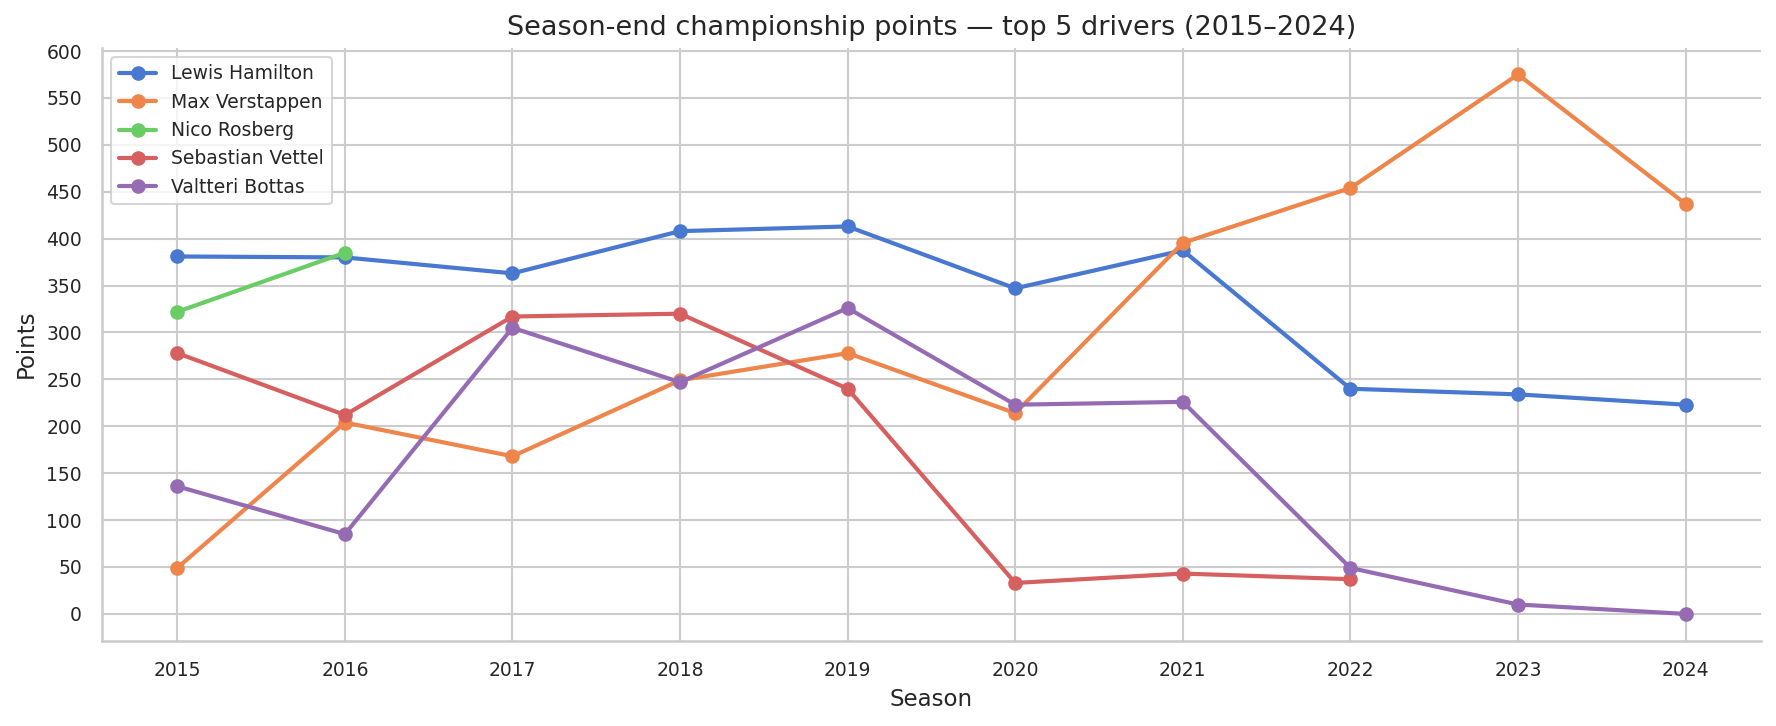

In [26]:
# Pick the 5 drivers with most total wins across all seasons
top5_drivers = (
    driver_summary.head(5)["driver_name"].tolist()
)

df_top5 = df_drivers[df_drivers["driver_name"].isin(top5_drivers)]

fig, ax = plt.subplots(figsize=(12, 5))

for driver, grp in df_top5.groupby("driver_name"):
    grp = grp.sort_values("season")
    ax.plot(grp["season"], grp["points"], marker="o", linewidth=2, label=driver)

ax.set_title("Season-end championship points — top 5 drivers (2015–2024)")
ax.set_xlabel("Season")
ax.set_ylabel("Points")
ax.set_xticks(range(2015, 2025))
ax.legend(loc="upper left", fontsize=9)
ax.yaxis.set_major_locator(mticker.MultipleLocator(50))
sns.despine()
plt.tight_layout()
plt.savefig("chart1_driver_points_trend.png", dpi=150)
plt.show()

Chart 2: Constructor dominance (wins per season)

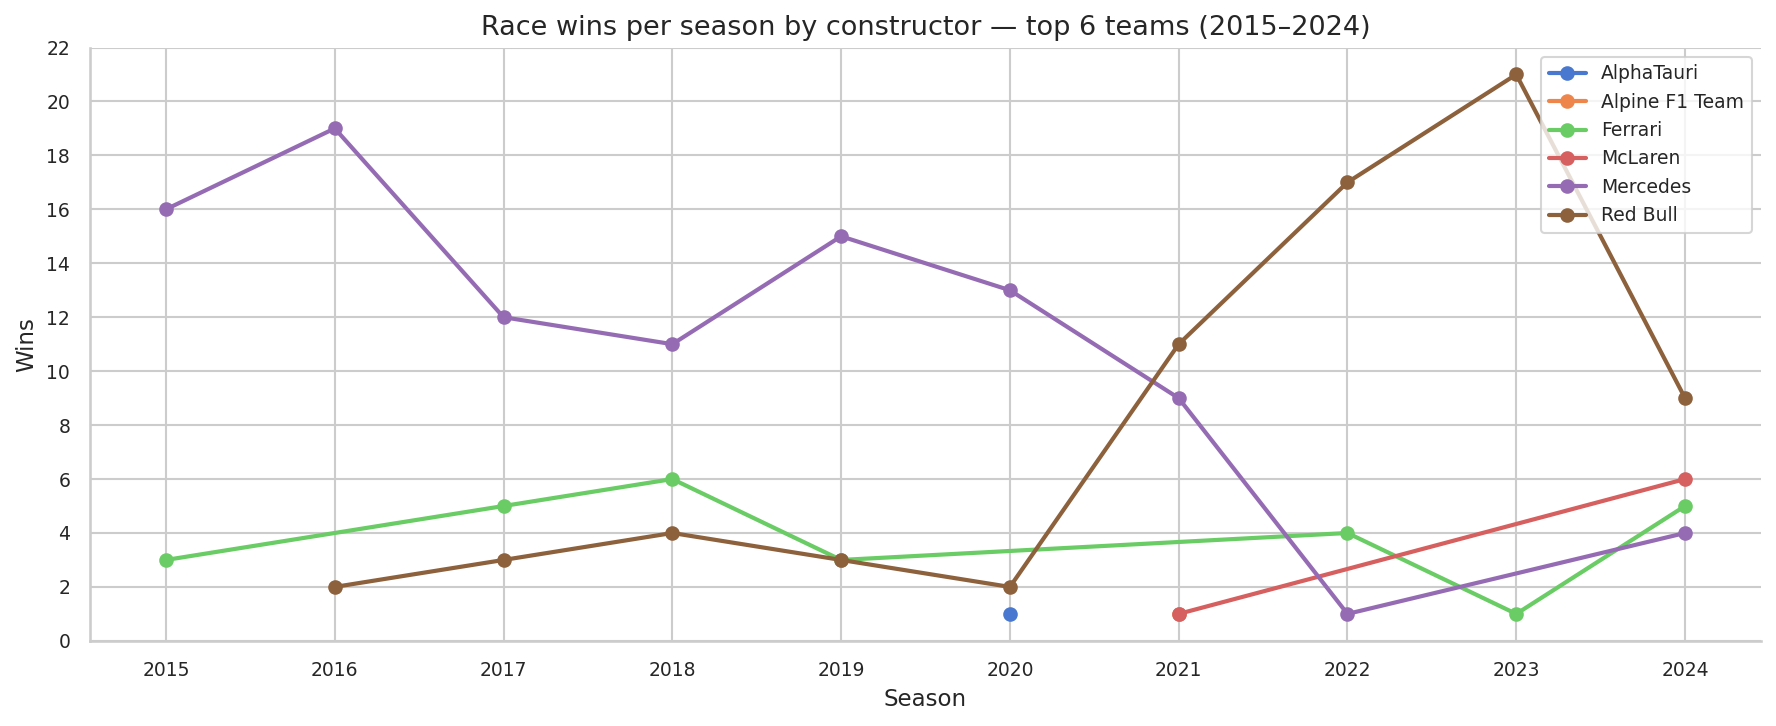

In [27]:
# Top 6 constructors by total wins
top6_teams = (
    constructor_summary.head(6)["constructor_name"].tolist()
)

wins_by_team_season = (
    df_results[df_results["constructor_name"].isin(top6_teams) & df_results["win"]]
    .groupby(["season", "constructor_name"])["win"]
    .sum()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(12, 5))

for team, grp in wins_by_team_season.groupby("constructor_name"):
    grp = grp.sort_values("season")
    ax.plot(grp["season"], grp["win"], marker="o", linewidth=2, label=team)

ax.set_title("Race wins per season by constructor — top 6 teams (2015–2024)")
ax.set_xlabel("Season")
ax.set_ylabel("Wins")
ax.set_xticks(range(2015, 2025))
ax.yaxis.set_major_locator(mticker.MultipleLocator(2))
ax.legend(loc="upper right", fontsize=9)
sns.despine()
plt.tight_layout()
plt.savefig("chart2_constructor_wins.png", dpi=150)
plt.show()

Chart 3: Win rate and podium rate — top 15 drivers

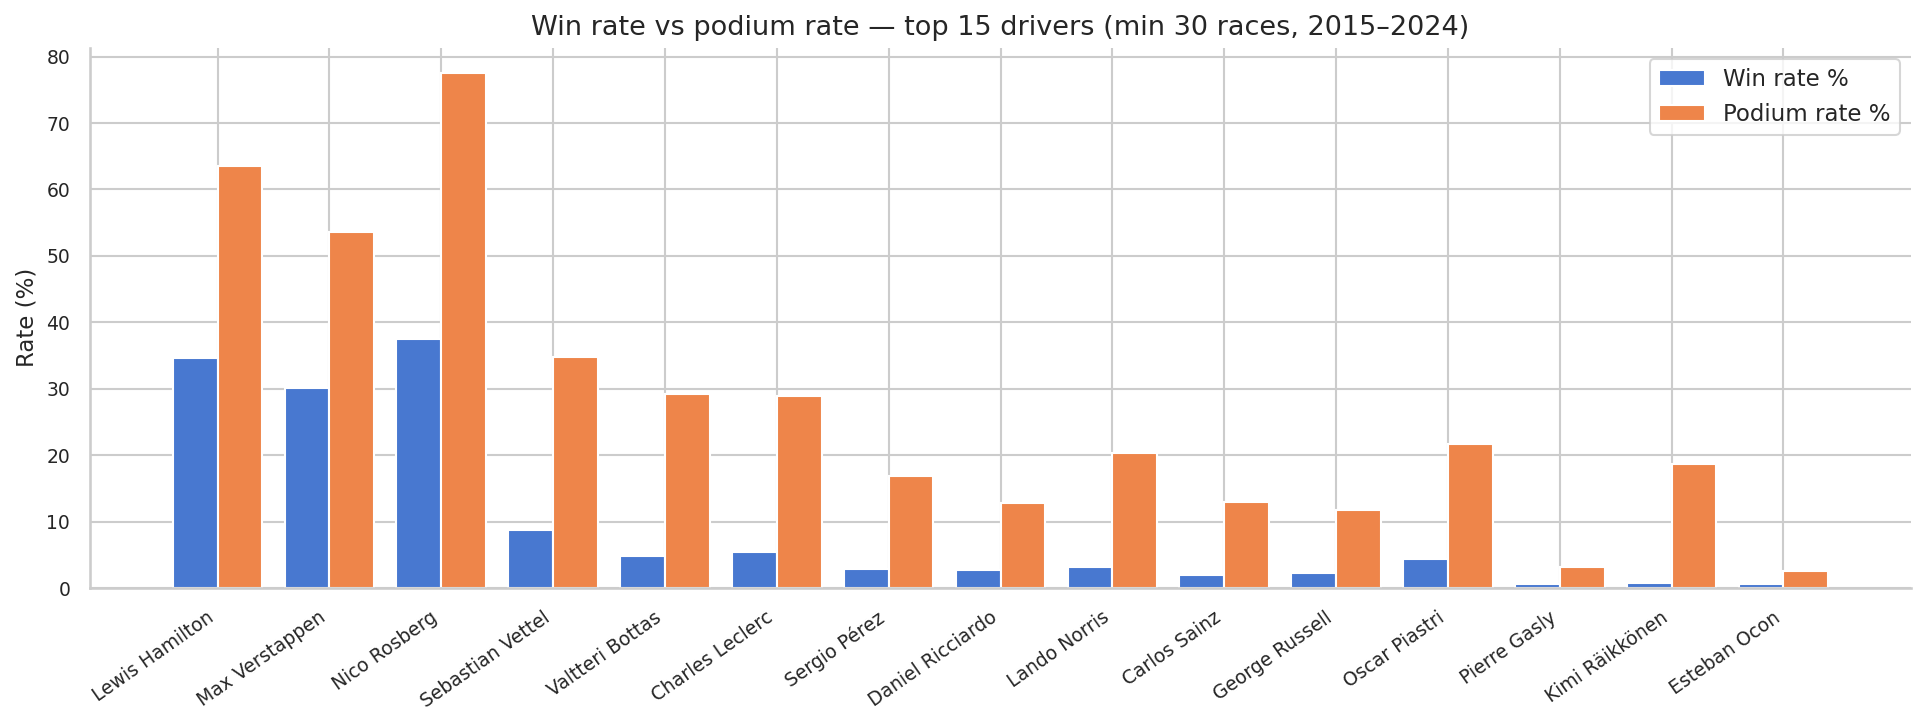

In [28]:
top15 = driver_summary[driver_summary["races"] >= 30].head(15)

x = range(len(top15))
width = 0.4

fig, ax = plt.subplots(figsize=(13, 5))
bars1 = ax.bar([i - width/2 for i in x], top15["win_rate"],    width=width, label="Win rate %",    color="#4878d0")
bars2 = ax.bar([i + width/2 for i in x], top15["podium_rate"], width=width, label="Podium rate %", color="#ee854a")

ax.set_xticks(list(x))
ax.set_xticklabels(top15["driver_name"], rotation=35, ha="right")
ax.set_ylabel("Rate (%)")
ax.set_title("Win rate vs podium rate — top 15 drivers (min 30 races, 2015–2024)")
ax.legend()
sns.despine()
plt.tight_layout()
plt.savefig("chart3_driver_win_podium_rate.png", dpi=150)
plt.show()

Chart 4: Grid position vs finish position (does qualifying matter?)

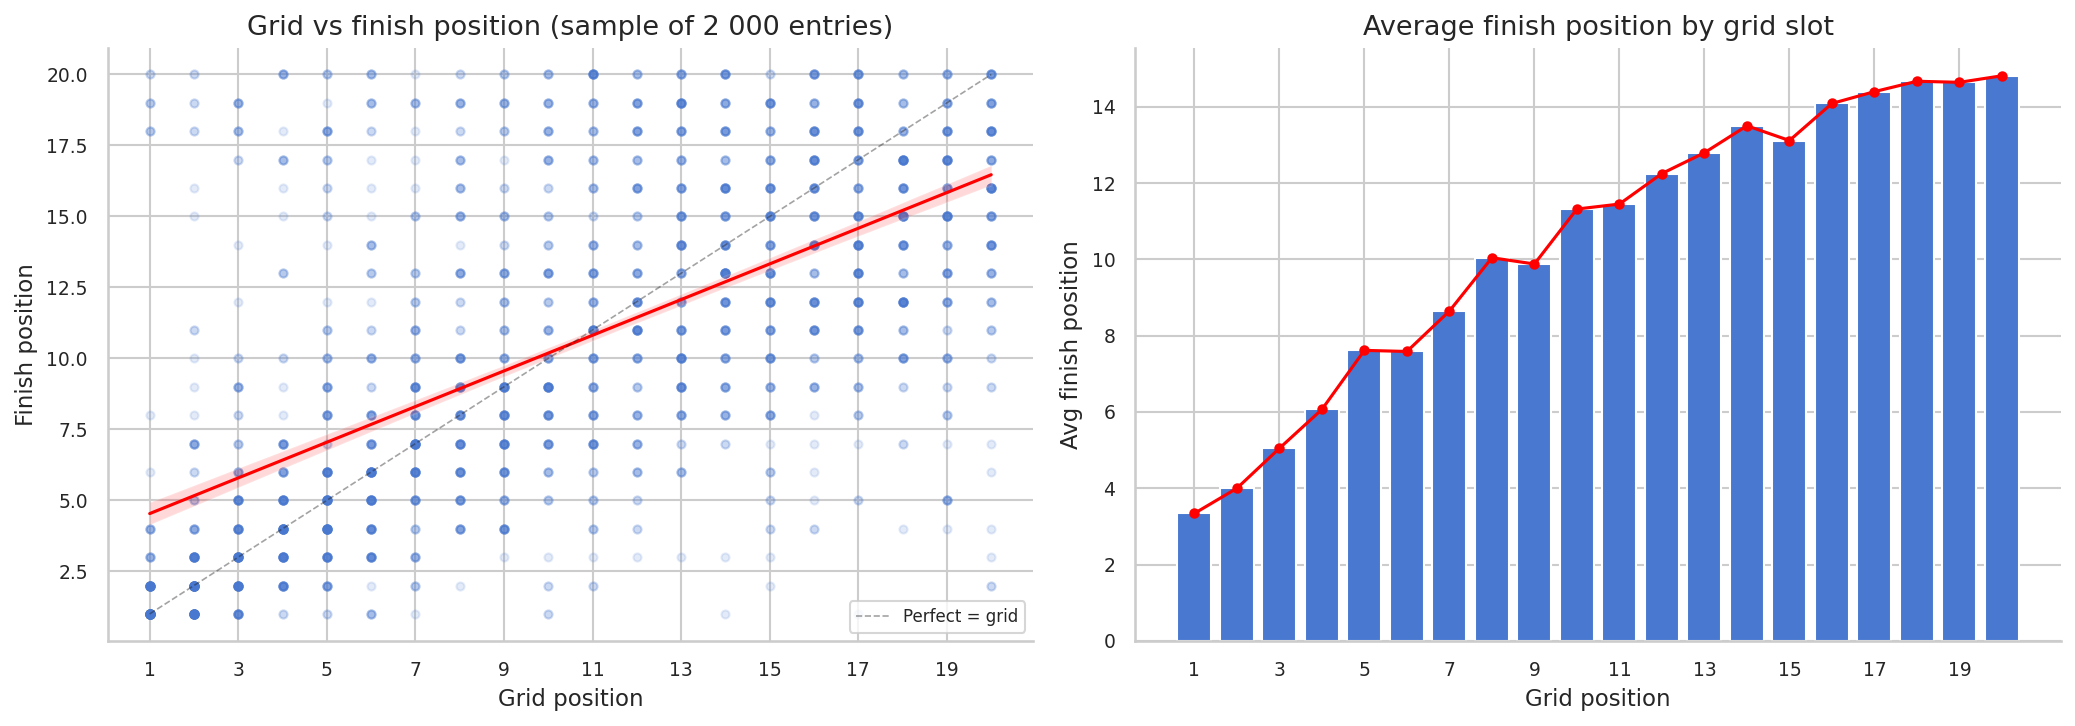

In [29]:
# Filter to classified finishes only, grids 1–20
plot_df = df_results[
    (df_results["grid_position"].between(1, 20)) &
    (df_results["finish_position"].between(1, 20))
].copy()

# Average finish position for each grid slot
avg_finish = (
    plot_df.groupby("grid_position")["finish_position"]
    .mean()
    .reset_index()
    .rename(columns={"finish_position": "avg_finish"})
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left — scatter with regression line
sns.regplot(
    data=plot_df.sample(2000, random_state=42),
    x="grid_position", y="finish_position",
    scatter_kws={"alpha": 0.15, "s": 15, "color": "#4878d0"},
    line_kws={"color": "red", "linewidth": 1.5},
    ax=axes[0]
)
axes[0].set_title("Grid vs finish position (sample of 2 000 entries)")
axes[0].set_xlabel("Grid position")
axes[0].set_ylabel("Finish position")
axes[0].plot([1,20],[1,20], "k--", linewidth=0.8, alpha=0.4, label="Perfect = grid")
axes[0].legend(fontsize=8)

# Right — average finish per grid slot
axes[1].bar(avg_finish["grid_position"], avg_finish["avg_finish"], color="#4878d0", edgecolor="white")
axes[1].plot(avg_finish["grid_position"], avg_finish["avg_finish"], "o-", color="red", linewidth=1.5, markersize=4)
axes[1].set_title("Average finish position by grid slot")
axes[1].set_xlabel("Grid position")
axes[1].set_ylabel("Avg finish position")

for ax in axes:
    ax.set_xticks(range(1, 21, 2))
    sns.despine(ax=ax)

plt.tight_layout()
plt.savefig("chart4_grid_vs_finish.png", dpi=150)
plt.show()

Downloading all charts

In [30]:
from google.colab import files
for chart in [
    "chart1_driver_points_trend.png",
    "chart2_constructor_wins.png",
    "chart3_driver_win_podium_rate.png",
    "chart4_grid_vs_finish.png",
]:
    files.download(chart)
print("All charts downloaded")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

All charts downloaded
